# Step 1.1 — NAIP Tile Download & Data Prep

Downloads raw NAIP COG tiles **directly from AWS Open Data** via STAC — no GEE, no GCS, no egress cost.
Stitches into a GDAL VRT for downstream pixel-level segmentation.

**Data source:** `s3://naip-analytic/` (public, free) via Element84 STAC `earth-search.aws.element84.com/v1`

**Output:** `data/naip/nyc/2022/`
- `*.tif` — individual NAIP COG tiles (R, G, B, NIR at 1m)
- `naip_nyc_2022.vrt` — GDAL virtual raster (seamless mosaic)
- `naip_nyc_2022.json` — sidecar: band order, CRS, bounds, tile count

> GEE is **not needed** for this step. It is initialized in later steps (1.3 NLCD masks).

## Cell 1 — Imports & Config

In [ ]:
%load_ext autoreload
%autoreload 2
from vacant_lot.config import load_config, _get_shared_root
from vacant_lot.tile_export import (
    download_naip_tiles,
    merge_tiles_to_vrt,
    query_naip_stac,
)

SHARED_ROOT = _get_shared_root()

config = load_config("nyc_buildings.yaml")

print(f"City:      {config.city_name}")
print(f"Run key:   {config._run_key()}")
print(f"NAIP year: {config.naip.year}")
print(f"bbox:      {config.segmentation.bbox}")

## Cell 2 — Create Output Directories

In [ ]:
config.ensure_seg_output_dirs()
tiles_dir = config.get_naip_tiles_dir()
print(f"Tiles dir: {tiles_dir}")

## Cell 3 — Query NAIP STAC

No credentials needed — `naip-analytic` is a public AWS Open Data bucket indexed by Element84.

In [ ]:
bbox = config.segmentation.bbox  # (west, south, east, north)

items = query_naip_stac(
    bbox=bbox,
    year=config.naip.year,
)

print(f"Found {len(items)} NAIP tiles")
print(f"Example item: {items[0].id}")
print(f"Assets: {list(items[0].assets.keys())}")

20:10:36 | INFO | vacant_lots | Querying Planetary Computer NAIP STAC for year=2022, bbox=(-74.27, 40.49, -73.7, 40.92)
20:10:37 | INFO | vacant_lots | Found 85 NAIP tiles
Found 85 NAIP tiles
Example item: ny_m_4007439_nw_18_060_20221007
Assets: ['image', 'thumbnail', 'tilejson', 'rendered_preview']


## Cell 4 — Download Tiles from S3

Downloads from -----
**MAC: run caffeinate -i in any terminal for this long running task**

In [ ]:
local_tile_paths = download_naip_tiles(
    items=items,
    local_dir=tiles_dir,
)

print(f"Downloaded {len(local_tile_paths)} tiles to {tiles_dir}")
print(f"Disk usage: {sum(p.stat().st_size for p in local_tile_paths) / 1e9:.2f} GB")

## Cell 5 — Build GDAL VRT

In [ ]:
from vacant_lot.tile_export import build_naip_vrt

# Dates 20220710, 20220720, 20220722 are NJ-only tiles identified after manual
# QGIS inspection (see Tests section below) — excluded from the NYC mosaic.
EXCLUDE_DATES = {"20220710", "20220720", "20220722"}

output_vrt = config.get_naip_vrt_path()
build_naip_vrt(tiles_dir, output_vrt, exclude_dates=EXCLUDE_DATES)
print(f"VRT created: {output_vrt}")

## Cell 6 — Verification

{
  "tile_count": 47,
  "band_order": [
    "R",
    "G",
    "B",
    "NIR"
  ],
  "crs": "EPSG:26918",
  "bounds": [
    558000.0,
    4476342.0,
    611310.0,
    4532850.0
  ]
}

VRT shape:  94180 × 88850 px
Band count: 4  (expected 4: R, G, B, NIR)
CRS:        EPSG:26918
Bounds:     BoundingBox(left=558000.0, bottom=4476342.0, right=611310.0, top=4532850.0)


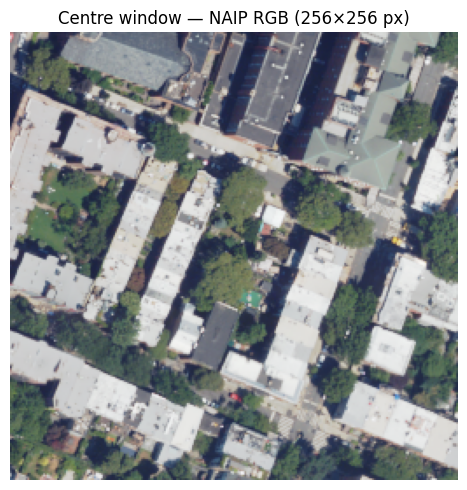

Verification passed.


In [ ]:
import json
import numpy as np
import rasterio
from rasterio.windows import Window
import matplotlib.pyplot as plt

# Print sidecar
sidecar = json.loads(output_vrt.with_suffix(".json").read_text())
print(json.dumps(sidecar, indent=2))

with rasterio.open(output_vrt) as ds:
    print(f"\nVRT shape:  {ds.height} × {ds.width} px")
    print(f"Band count: {ds.count}  (expected 4: R, G, B, NIR)")
    print(f"CRS:        {ds.crs}")
    print(f"Bounds:     {ds.bounds}")

    assert ds.count == 4, f"Expected 4 bands, got {ds.count}"

    # Read 256×256 window from centre
    cx, cy = ds.width // 2, ds.height // 2
    window = Window(cx - 128, cy - 128, 256, 256)
    rgb = ds.read([1, 2, 3], window=window)  # R, G, B

assert rgb.max() > 0, "Window is all-zero — check tile coverage"
assert 0 <= rgb.min() and rgb.max() <= 255

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(np.moveaxis(rgb, 0, -1))
ax.set_title("Centre window — NAIP RGB (256×256 px)")
ax.axis("off")
plt.tight_layout()
plt.show()

print("Verification passed.")

# Step 1.2 — Generate Pixel-Level Label Masks

Burns MapPLUTO parcel polygons onto the NAIP VRT grid to produce:
- **vacancy mask** (`vacancy_mask.tif`): `0` = non-vacant, `1` = vacant, `255` = ignore (nodata / boundary ring)
- **borough mask** (`borough_mask.tif`): `1`–`5` = BoroCode, `0` = nodata

Both masks share the exact affine transform, CRS, width, and height of the VRT.

## Pixel Mask Imports

In [ ]:
from vacant_lot.data_utils import load_gdb
from vacant_lot.label_utils import create_vacancy_mask, create_borough_mask

## Load Data (MapPLUTO GDB, NAIP VRT)

In [ ]:
vrt_path = config.get_naip_vrt_path()
masks_dir = config.get_seg_masks_dir()
config.ensure_seg_output_dirs()

gdb_path = config.get_parcel_path()
print(f"GDB path: {gdb_path}")
print(f"VRT path: {vrt_path}")
print(f"Masks dir: {masks_dir}")

# Load all parcels (no subset_size — we need the full ~800k lots)
parcel_gdf = load_gdb(str(gdb_path), layer=config.parcel.layer)
print(f"Loaded {len(parcel_gdf):,} parcels")

## Omit Parcels in Shadow + Figure

Parcels after omission: 856,990 (9 omitted)


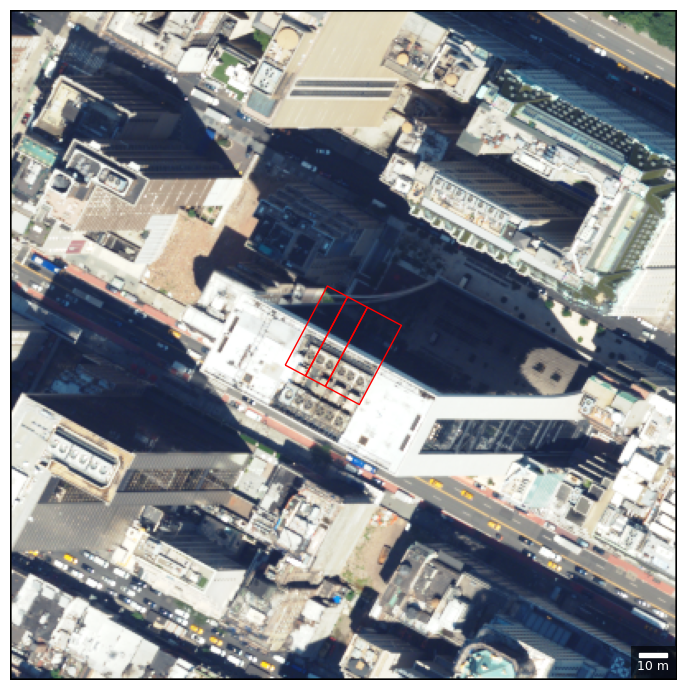

In [ ]:
from vacant_lot.plotting import plot_naip_parcels, save_figure

# BBLs to manually exclude from the vacancy mask (set to 255 / nodata)
# Add BBLs here after visual inspection in QGIS
# BBLs mainly in shadow
OMIT_BBLS = [400434001,1012730015,1012730016,1012730017,1012720050,1012720005,1012720007,1007100060,1012720069]


parcel_gdf_filtered = parcel_gdf[~parcel_gdf["BBL"].isin(OMIT_BBLS)].copy()
print(f"Parcels after omission: {len(parcel_gdf_filtered):,} ({len(OMIT_BBLS)} omitted)")


SHADOW_BBLS = [1012730015, 1012730016, 1012730017]

shadow_parcels = parcel_gdf[parcel_gdf["BBL"].isin(SHADOW_BBLS)].to_crs("EPSG:26918")

fig = plot_naip_parcels(vrt_path, shadow_parcels, context_m=100)
plt.show()

# save_figure(fig, masks_dir / "omitted_shadow_lots.png")
# save_figure(fig, config.get_final_figures_dir() / "omitted_shadow_lots.png")

## Create Vacancy Mask

In [ ]:
vacancy_mask_path = masks_dir / "vacancy_mask.tif"

vacancy_mask_path = create_vacancy_mask(
    parcel_gdf=parcel_gdf_filtered,
    cfg=config,
    reference_raster_path=vrt_path,
    output_path=vacancy_mask_path,
    erosion_pixels=2,
)
print(f"Vacancy mask: {vacancy_mask_path}")

## Create Borough Mask

In [ ]:
borough_mask_path = masks_dir / "borough_mask.tif"

borough_mask_path = create_borough_mask(
    reference_raster_path=vrt_path,
    output_path=borough_mask_path,
)
print(f"Borough mask: {borough_mask_path}")

20:32:39 | INFO | vacant_lots | Labels: 30784 vacant (3.6%) out of 856990 parcels


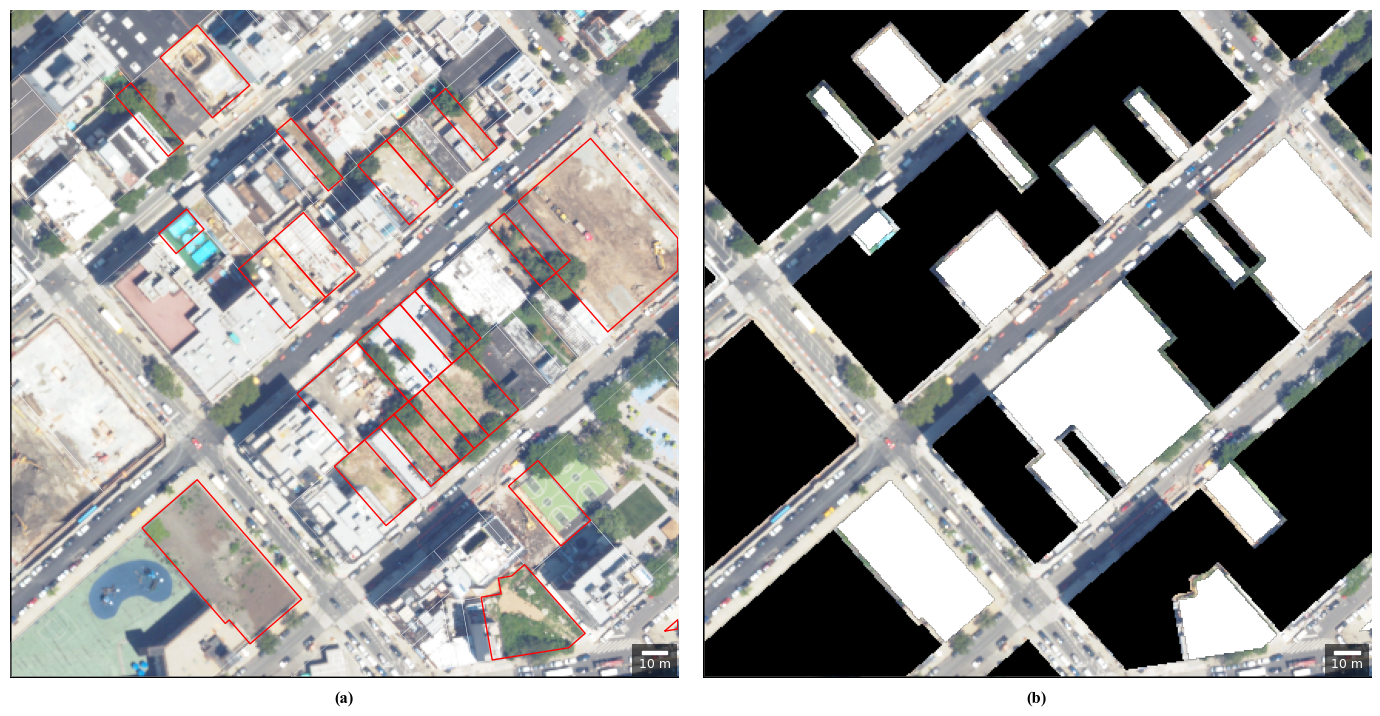

In [ ]:
import matplotlib.pyplot as plt
from vacant_lot.modeling import build_labels
from vacant_lot.plotting import plot_vacancy_overview, save_figure

export_gdf = parcel_gdf_filtered.to_crs("EPSG:26918").copy()
export_gdf["is_vacant"] = build_labels(export_gdf, config)

fig = plot_vacancy_overview(
    naip_vrt=vrt_path,
    export_gdf=export_gdf,
    vacancy_mask_path=vacancy_mask_path,
    cx=588920.5, cy=4506140.0, radius=130,
)
plt.show()

# save_figure(fig, masks_dir / "vacancy_mask.png")
# save_figure(fig, config.get_final_figures_dir() / "vacancy_mask.png")

---
## Tests

Scratch cells for manual inspection — outputs go to `./tmp/` (gitignored).

In [ ]:
# Build one VRT per acquisition date for QGIS inspection
# Output: tmp/naip_vrt_date_tests/ (gitignored)
# Paths inside each VRT are rewritten to absolute so QGIS resolves tiles correctly.
import xml.etree.ElementTree as ET
from collections import defaultdict
from pathlib import Path

def make_vrt_paths_absolute(vrt_path: Path) -> None:
    """Rewrite all SourceFilename entries in a VRT to absolute paths."""
    tree = ET.parse(vrt_path)
    root = tree.getroot()
    vrt_dir = vrt_path.parent.resolve()
    for elem in root.iter("SourceFilename"):
        raw = elem.text.strip()
        resolved = (vrt_dir / raw).resolve()
        elem.set("relativeToVRT", "0")
        elem.text = str(resolved)
    tree.write(vrt_path)

out_dir = (SHARED_ROOT / "tmp" / "naip_vrt_date_tests").resolve()
out_dir.mkdir(parents=True, exist_ok=True)

by_date = defaultdict(list)
for p in tiles_dir.glob("*.tif"):
    date = p.stem.split("_")[-1]
    by_date[date].append(p)

for date, tiles in sorted(by_date.items()):
    vrt = out_dir / f"naip_{date}.vrt"
    merge_tiles_to_vrt(tiles, vrt)
    make_vrt_paths_absolute(vrt)
    print(f"{date}: {len(tiles)} tiles → {vrt}")

In [ ]:
# count # of pixels in BBL after vacancy mask put on it

from rasterio.mask import mask as rio_mask

TARGET_BBL = 1013110013

parcel = parcel_gdf[parcel_gdf["BBL"] == TARGET_BBL]
assert len(parcel) == 1, f"Expected 1 parcel, got {len(parcel)}"

geom = parcel.to_crs("EPSG:26918").geometry

with rasterio.open(vacancy_mask_path) as src:
    clipped, _ = rio_mask(src, geom, crop=True, nodata=255)
    pixels = clipped[0]

vacant    = (pixels == 1).sum()
nonvacant = (pixels == 0).sum()
nodata    = (pixels == 255).sum()
total     = pixels.size

print(f"BBL {TARGET_BBL}")
print(f"  vacant    (1): {vacant:,}")
print(f"  non-vacant(0): {nonvacant:,}")
print(f"  nodata  (255): {nodata:,}")
print(f"  total        : {total:,}")